In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [106]:
N=100

x_1_list = []

for i in range(N):
    x_1_list.append(i*1.9)
    
x_2 = np.zeros(N)

df_1 = pd.DataFrame(columns = ['x_1', 'x_2'])
df_1['x_1'] = x_1_list
df_1['x_2'] = x_2

x_1_list = []

for i in range(N):
    x_1_list.append(1 + i*1.9)
    
x_2 = np.ones(N) 

df_2 = pd.DataFrame(columns = ['x_1', 'x_2'])
df_2['x_1'] = x_1_list
df_2['x_2'] = x_2

df = pd.concat([df_1, df_2])
df['y'] = df['x_2'].astype(int)

X = df.drop(columns = ['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

EU_accuracy_train = accuracy_score(y_train, y_pred_train)
EU_accuracy_test = accuracy_score(y_test, y_pred_test)

knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

MA_accuracy_train = accuracy_score(y_train, y_pred_train)
MA_accuracy_test = accuracy_score(y_test, y_pred_test)

print('EU_accuracy_train =', round(EU_accuracy_train, 4))
print('EU_accuracy_test  =', round(EU_accuracy_test, 4))
print('')
print('MA_accuracy_train =', round(MA_accuracy_train, 4))
print('MA_accuracy_test  =', round(MA_accuracy_test, 4))
print('')
print('Прирост скора = ', round(MA_accuracy_test - EU_accuracy_test, 4))


EU_accuracy_train = 0.6357
EU_accuracy_test  = 0.2167

MA_accuracy_train = 0.8857
MA_accuracy_test  = 0.65

Прирост скора =  0.4333


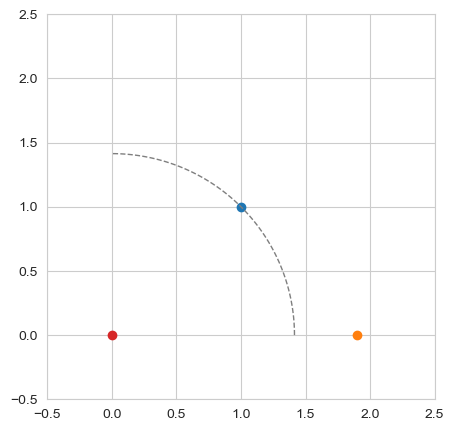

In [126]:
plt.figure(figsize=(5,5))
plt.xlim([-0.5, 2.5])
plt.ylim([-0.5, 2.5])

plt.plot(0, 0, 'o', color = 'C3')
plt.plot(1, 1, 'o', color = 'C0')
plt.plot(1.9, 0, 'o', color = 'C1')

circle_x = []
circle_y = []

for t in np.linspace(0, 3.1415926/2, 100):
    circle_x.append(2**0.5 * np.cos(t))
    circle_y.append(2**0.5 * np.sin(t))

plt.plot(circle_x, circle_y, '--', color='C7', lw=1)
    
plt.grid(True)
plt.show()